In [1]:
import os
import sys
import copy as cp
import importlib
import pandas as pd
import numpy as np
import math
import string
import pickle
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import scipy
from scipy import stats
import seaborn as sns

from datetime import date

In [2]:
sys.path.append(os.path.abspath('../code/'))

from data_functions import *
from data_plotting_functions import *
from maxima_functions import count_local_maxima_step

In [3]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.titlesize'] = 8    # Size of the plot title
plt.rcParams['axes.labelsize'] = 8    # Size of x and y labels
plt.rcParams['xtick.labelsize'] = 7   # Size of x-tick labels
plt.rcParams['ytick.labelsize'] = 7   # Size of y-tick labels
plt.rcParams['legend.fontsize'] = 7
plt.rcParams['font.size'] = 8

plt.rcParams.update({
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.minor.size': 2,
    'ytick.minor.size': 2,
    'xtick.major.pad': 2,
    'ytick.major.pad': 2,
    'axes.linewidth': 0.8,
})

cm_to_inch = 2.54

In [4]:
study = 'GB1'
study   = 'ParD3-ParE3'
study   = 'ParD3-ParE2'

if study == 'GB1' :
    seed = 131531
elif 'ParE3' in study :
    seed = 129505
elif 'ParE2' in study :
    seed = 563291

In [5]:
# whether to save figures
save = True

# Create the directory
outputdir = '../results/CMEs/' + str (date.today())
os.makedirs(outputdir, exist_ok=True)
outputdir = os.path.join (outputdir, study)
os.makedirs(outputdir, exist_ok=True)

# first order effects and R2 statistics
inputdir = os.path.join ('CMEs', '2026-09-27')
F1s      = np.loadtxt (os.path.join ('../results/', inputdir, study, 'f1s_' + study + '.txt'))
R2_all   = np.loadtxt (os.path.join ('../results/', inputdir, study, 'ols_reg_' + study + '.txt'))

In [6]:
my_colors  = ['gold','cornflowerblue','salmon','dimgray','lightgray']
scenarios  = ['beneficial','deleterious','adaptive','conditional','random']
color_dict = dict (zip (scenarios, my_colors))

# permutation test
nsims  = 100
nperm  = 100
ntypes = len (scenarios)

In [7]:
# amino acid to numeric dictionary
aa_dict = default_aa_dict ( alphabetical=True )

if '*' in aa_dict.keys() :
    del aa_dict['*']

In [8]:
if study == 'GB1' :
    pc = 1 # pseudo-count

    # location of data
    datadir = '../data'
    dataset = 'wu_et_al_fitness_values.csv'

    M = 4 # number of loci
    
    # wt sequence is the first row
    df    = pd.read_csv (os.path.join (datadir, dataset))
    nlib  = df.shape[0] # number of genotypes
    
    # convert genotypes to numeric code
    genos = np.zeros ((nlib, M), dtype=int)
    for i in range (nlib) :
        genos[i,:] = aa_to_numeric (df['Variants'][i], aa_to_int=aa_dict)

    # log transform read counts with pseudo-count
    phenos = np.array ( np.log10 ((df['Count selected']+pc) / (df['Count input']+pc) ))

    # initial and post-selection reads
    N0 = np.array (df['Count input'], dtype=int)
    N1 = np.array (df['Count selected'], dtype=int)


elif study == 'ParD3-ParE2' or study == 'ParD3-ParE3' :

    # location of data
    datadir = '../data/' + str (study) + ' Lite/'
    geno_file  = 'genotypes.txt'
    pheno_file = 'phenotypes.txt'

    genos   = np.loadtxt (os.path.join (datadir, geno_file), delimiter=',', dtype=int)
    nlib, M = genos.shape
    phenos  = np.loadtxt ( os.path.join (datadir, pheno_file) )
    
else :
    print ('Study not recognized.')

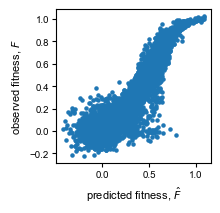

In [9]:
yhats = np.zeros (nlib)
for i in range (nlib) :
    for m in range (M) :
        yhats[i] += F1s[genos[i,m]-1,m]

plt.rcParams['figure.figsize'] = (2,2)
plt.scatter (yhats + np.mean (phenos), phenos, s=5)
plt.xlabel (r'predicted fitness, $\hat F$')
plt.ylabel (r'observed fitness, $F$')
plt.show ()

In [10]:
# random number generator
my_rng = np.random.default_rng (seed)

In [11]:
R2     = np.zeros ((ntypes, nsims, M+1))
nMax   = np.zeros ((ntypes, nsims, M+1))
nPaths = np.zeros ( (ntypes, nsims) )
ancestors = np.zeros (nsims, dtype=int)

R2_perm = np.zeros ( (nsims, ntypes, nperm, M+1) )
R2_obs  = np.zeros ( (nsims, ntypes, M+1) )

Ys = np.zeros ((ntypes, nsims, 2**M))
Xs = np.zeros ((ntypes, nsims, 2**M, M))
Reads = np.zeros ((ntypes, nsims, M), dtype=int)
Reads_del = np.zeros ((nsims, 2**M-M), dtype=int)
Ia = np.zeros ((ntypes, nsims, 2**M), dtype=int)
XM = np.zeros ((ntypes, nsims), dtype=int)


si = 0
while si < nsims :

    anc_idx  = my_rng.choice ( np.arange (0, nlib, 1) )
    ancestor = cp.deepcopy (genos[anc_idx,:])
    ancestors[si] = anc_idx

    try :
        R2[:,si,:], nMax[:,si,:], nPaths[:,si], Coefs, mydict = simulate_from_common_ancestor (ancestor, genos, phenos,
                                                                                               ntries=10, epsilon=0.01, weighted=False,
                                                                                               rng=my_rng)

        ct = 0
        for scen in mydict.keys () :
            ids = cp.deepcopy (mydict[scen][2])
            X   = cp.deepcopy (mydict[scen][0])
            ys  = cp.deepcopy (mydict[scen][1])

            derived = np.where (np.sum (X, axis=1) == M)[0][0]
            XM[ct, si] = np.array (ids)[derived]

            
            if study == 'GB1' :
                singles    = np.where (np.sum (X, axis=1) == 1)[0]
                id_singles = np.array (ids)[singles]
                Reads[ct, si, :] = cp.deepcopy ( N0[id_singles] )

                if ct == 1 :
                    not_singles = np.where (np.sum (X, axis=1) != 1)[0]
                    ids_not_singles = np.array (ids)[not_singles]
                    Reads_del[si,:] = cp.deepcopy ( N0[ids_not_singles] )

            Ys[ct, si, :]    = cp.deepcopy (ys)
            Xs[ct, si, :, :] = cp.deepcopy (X)
            Ia[ct,si, :]     = cp.deepcopy (ids)
            
            R2_perm[si,ct,:,:], R2_obs[si,ct,:] = permute_r2 (X, ys, B=nperm, rng=my_rng)
            
            ct += 1            

        si += 1

    except Exception as e :
        print (e)
        

Attempt 1 failed: Trajectory is too short: 1
Attempt 2 failed: Trajectory is too short: 1
Attempt 1 failed: Trajectory is too short: 1
Attempt 2 failed: Trajectory is too short: 1
Attempt 3 failed: Trajectory is too short: 1
Attempt 4 failed: Trajectory is too short: 1
Attempt 5 failed: Trajectory is too short: 1
Attempt 6 failed: Trajectory is too short: 1
Attempt 7 failed: Trajectory is too short: 1
Attempt 8 failed: Trajectory is too short: 1
Attempt 1 failed: The library is too small: 7
Attempt 1 failed: The library is too small: 7
The library is too small: 7
Attempt 1 failed: The library is too small: 6
The library is too small: 6
Attempt 1 failed: Trajectory is too short: 1
Attempt 2 failed: Trajectory is too short: 1
Attempt 3 failed: Trajectory is too short: 1
Attempt 4 failed: Trajectory is too short: 1
Attempt 5 failed: Trajectory is too short: 1
Attempt 6 failed: Trajectory is too short: 1
Attempt 7 failed: Trajectory is too short: 1
Attempt 8 failed: Trajectory is too short

In [12]:
# save all simulation output to files
with open( os.path.join (outputdir, 'R2_' + study + '.pkl'), 'wb') as file:
    pickle.dump(R2, file)

with open( os.path.join (outputdir, 'nmax_' + study + '.pkl'), 'wb') as file:
    pickle.dump(nMax, file)

Ia = np.array (Ia, dtype=int) 
with open( os.path.join (outputdir, 'Ia_' + study + '.pkl'), 'wb') as file:
    pickle.dump(Ia, file)

np.savetxt ( os.path.join (outputdir, 'npaths_' + study + '.txt'), nPaths )
np.savetxt ( os.path.join (outputdir, 'phenos_' + study + '.txt'), phenos )

In [13]:
# Read distributions plot for GB1
if study == 'GB1' :
    
    KSreads = np.zeros ((ntypes+1, ntypes+1))
    for i in range (ntypes) :
        KSreads[i,-1] = KSreads[-1,i] = stats.kstest (np.ndarray.flatten (Reads[i,:,:]), N0).pvalue
        for j in range (i+1,ntypes) :
            KSreads[i,j] = KSreads[j,i] = stats.kstest (np.ndarray.flatten (Reads[i,:,:]), np.ndarray.flatten (Reads[j,:,:])).pvalue
    
    plt.rcParams['figure.figsize'] = (6,2)
    fig, axs = plt.subplots (1,3, width_ratios=(1.75,1.75,2), sharex=False, sharey=False, constrained_layout=True)
    
    ax = axs[0]
    for i in range (ntypes) :
        ax.ecdf (np.ndarray.flatten (Reads[i,:,:]), color=color_dict[scenarios[i]], label=scenarios[i][:4])
    
    ax.ecdf (N0, color='black', linestyle='--', linewidth=1, label='glob')
    ax.legend (frameon=False, handlelength=1)
    #plt.show ()
    ax.set_xscale ('log')
    ax.set_xlabel (r'initial read count, $N_0$')
    ax.set_ylabel ('cdf')
    ax.set_title (r'$\mathbf{A}$', loc='left', pad=.5,)
    ax.set_ylim ((-0.05,1.05))
    
    ax = axs[1]
    ax.ecdf (np.ndarray.flatten (Reads_del), color='navy', linestyle='dotted', label=r'$m \neq 1$')
    ax.ecdf (np.ndarray.flatten (Reads[1,:,:]), color=color_dict['deleterious'], label=r'$m=1$')
    ax.set_xscale ('log')
    ax.legend (frameon=False, handlelength=1)
    ax.set_xlabel (r'initial read count, $N_0$')
    
    ks_del = stats.kstest (np.ndarray.flatten (Reads_del), np.ndarray.flatten (Reads[1,:,:])).pvalue
    ax.annotate (r'$p$=' + str (np.round (ks_del,4)), (10**2 + .5*10**3,.1))
    ax.set_ylim ((-0.05,1.05))
    
    ax.set_title (r'$\mathbf{B}$', loc='left', pad=.5)
    
    ax = axs[2]
    np.fill_diagonal (KSreads, np.nan)
    cow = ax.imshow (KSreads, norm=mpl.colors.LogNorm (), )
    
    ax.set_xticks(np.arange(len(scenarios)+1))
    labels = [x[:4] for x in scenarios]
    labels.append ('glob')
    ax.set_xticklabels(labels, rotation=45, ha="right") # Rotated for readability
    #ax.set_yticks(np.arange(len(scenarios)))
    ax.set_yticks(np.arange(len(scenarios)+1))
    ax.set_yticklabels(labels, rotation=0) # Rotated for readability

    #ax.set_yticklabels([''] * ntypes)
        
    for i in range (ntypes) :
        ax.scatter ( i, i, s=100, c=color_dict[scenarios[i]])
    
    ax.scatter (i+1, i+1, s=100, color='white', edgecolor='black', lw=.5)
    
    ax.set_title (r'$\mathbf{C}$', loc='left', pad=.5)
    fig.colorbar (cow, label='KS $p$-value')
    
    if save :
        plt.savefig (os.path.join (outputdir, 'reads_KS_test_' + study + '.pdf'), bbox_inches='tight')
        plt.close ()
    else :
        plt.show ()

In [14]:
# count allele occurrence in each scenario
nalleles = len (np.unique (genos))

AlleleCounts = np.zeros ((ntypes, M, nalleles), dtype=int)
for i in range (ntypes) :
    tmp_list = list ()
    for si in range (nsims) :
        tmp_list.append (genos[XM[i,si]])
    genos_i = np.vstack (tmp_list)

    for m in range (M) :
        for a in range (1,nalleles+1) :
            AlleleCounts[i,m,a-1] = np.sum (genos_i[:,m] == a)

In [15]:
# reverse amino acid dictionary
num_aa_dict = dict ()
for a in aa_dict.keys () :
    val = aa_dict[a]
    num_aa_dict[val] = a

In [16]:
ALLELE_AXIS = "columns"   # "columns" if each column is an allele; "rows" if each row is.
LOGO_TYPE   = "probability"      # "bits" = information (0-2 for DNA) or "probability" (0-1)

if study == 'GB1' :
    locus_labels = ['V39','D40','G41','V54']
else :
    locus_labels = ['D61','K64','E80']

plt.rcParams['figure.figsize'] = (6,3)
fig, axs = plt.subplots (2,3, constrained_layout=True)

logo_list = list ()
for i in range (ntypes) :
    outfile     = os.path.join (outputdir, 'sequence_logo_' + scenarios[i] + '.png')

    logo_list.append (build_logo (counts=AlleleCounts[i,:,:], int_to_letter=num_aa_dict,
                                  allele_axis=ALLELE_AXIS, logo_type=LOGO_TYPE, xaxis_labels=locus_labels,
                                  save=False, ax=axs[int (i/3),i % 3], title=string.ascii_uppercase[i]))

for i in range (2) :
    axs[i,0].set_ylabel ('Probability')
    axs[1,i].set_xlabel ('Locus')

axs[1, 2].set_visible(False)

if save :
    plt.savefig (os.path.join (outputdir, 'seq_logos_' + study + '.pdf'), bbox_inches='tight')
    plt.close ()
else :
    plt.show ()

In [17]:
LogoSim = np.zeros ((ntypes, ntypes)) * np.nan
for i in range (ntypes) :
    LogoSim[i,i] = np.mean (scipy.stats.entropy (logo_list[i], axis=1))
    for j in range (ntypes) :
        if j != i :
            LogoSim[i,j] = np.min (scipy.spatial.distance.jensenshannon (logo_list[i], logo_list[j], axis=1))
            LogoSim[j,i] = np.max (scipy.spatial.distance.jensenshannon (logo_list[i], logo_list[j], axis=1))

split_triangle_heatmap(
        LogoSim,
        upper_cmap="Reds",
        lower_cmap="Blues",
        diagonal_cmap="Greys",
        labels=scenarios,
        show_diagonal=True,
        annotate=True,
        outputdir=outputdir,
        title=string.ascii_uppercase[5]
    )   

In [18]:
# compute additive predictions
Add = np.zeros_like (Ia, dtype=float)
for i in range (nsims) :
    for t in range (ntypes) :
        ct = 0
        for g in genos[Ia[t,i,:],:] :
            for m in range (M) :
                #print (F1s[g[m]-1,m])
                Add[t,i,ct] += F1s[g[m]-1,m]
                #print ( (Add[t,i,ct], ct))
            
            ct += 1

Yd = np.zeros ((ntypes, nsims, M+1))
Ad = np.zeros_like (Yd)
for i in range (nsims) :
    for m in range (M+1) :
        for t in range (ntypes) :
            indices = np.where ( np.sum (Xs[t,i,:], axis=1) == m )[0]
            Yd[t,i,m] = np.mean (Ys[t, i, indices])
            Ad[t,i,m] = np.mean (Add[t, i, indices])

In [19]:
with open( os.path.join (outputdir, 'Yd_' + study + '.pkl'), 'wb') as file:
    pickle.dump (Yd, file)

with open( os.path.join (outputdir, 'Ad_' + study + '.pkl'), 'wb') as file:
    pickle.dump (Ad, file)

In [20]:
mu = np.mean (phenos)
print (mu)

0.23420600300291805


In [21]:
Ydif = np.zeros ((ntypes, nsims))
for n in range (ntypes) :
    for i in range (nsims) :
        nmuts = np.sum (Xs[n,i,:], axis=1)
        Ydif[n,i] = Ys[n,i,np.where (nmuts == M)[0][0]] - Ys[n,i,np.where (nmuts == 0)[0][0]]

In [22]:
nPaths = np.array (nPaths, dtype=int)

In [23]:
Cpaths = np.zeros ((math.factorial (M)+1, math.factorial (M)+1))
Ycomp  = np.zeros_like (Cpaths)
for i in range (nsims) :
    Cpaths[ nPaths[0,i], nPaths[2,i] ] += 1
    Ycomp[ nPaths[0,i], nPaths[2,i] ]  += (Ydif[0,i] - Ydif[2,i])

In [24]:
if study == 'GB1' :
    Csmall = pool_matrix_sums_numpy (Cpaths, 2)
    Ycomp_small = pool_matrix_sums_numpy (Ycomp, 2)
    Ycomp_small_norm = Ycomp_small / Csmall

    colors_pool = ["#008080", "#fcfcfc", "#ff7f0e"]
    my_cmap = mcolors.LinearSegmentedColormap.from_list("teal_orange", colors_pool)
    
    a = np.nanmax (np.abs (Ycomp_small_norm))
    # Create the normalization mapping from -a to a
    my_norm = mcolors.Normalize (vmin=-a, vmax=a)

In [25]:
if study == 'GB1' :
    plt.rcParams['figure.figsize'] = (4,4)
    
    fig, ax = plt.subplots ()
    
    n, n = Csmall.shape
    
    hm = ax.imshow (Csmall, cmap='Greys')
    ax.set_xticks ( np.arange (0,n,1),  np.arange (0,n,1)*2)
    ax.set_yticks ( np.arange (0,n,1),  np.arange (0,n,1)*2)
    ax.set_xlabel ('no. paths adaptive')
    ax.set_ylabel ('no. paths beneficial')
    
    fig.colorbar (hm, ax=ax, shrink=.7, label='no. simulations')
    
    for i in range (n) :
        for j in range (n) :
            if ~np.isnan (Ycomp_small_norm[i,j]) :
                mys = ax.scatter ( j, i, c=Ycomp_small_norm[i,j], cmap=my_cmap, norm=my_norm, edgecolor='black', linewidth=.5, s=40)
    
    # 4. Add a colorbar to read the continuous values
    cbar = fig.colorbar (mys, ax=ax, location='top', shrink=.75, label=r'$D^{bene} - D^{adap}$')
    #cbar.set_label('', rotation=0, labelpad=15)
    
    if save :
        plt.savefig (os.path.join (outputdir, 'bene_vs_adap_compressed_' + str (study) + '.pdf'), bbox_inches='tight')
        plt.close ()
    else :
        plt.show ()

In [26]:
# compute P-values for pairwise t-test of R2 values
P_r2 = np.zeros ((ntypes, ntypes)) * np.nan
P_w = np.zeros ((M+1, ntypes, ntypes)) * np.nan
P_p = np.zeros_like (P_r2) * np.nan
for i in range (ntypes) :
    for j in range (i+1, ntypes) :
        t_statistic, p_value = stats.ttest_rel (R2[i,:,1], R2[j,:,1])
        P_r2[i,j] = p_value
        P_r2[j,i] = np.mean ( R2[j,:,1] - R2[i,:,1])

        t_statistic, p_value = stats.ttest_rel (nPaths[i,:], nPaths[j,:])
        P_p[i,j] = p_value
        P_p[j,i] = np.mean ( nPaths[j,:] - nPaths[i,:])

        
        for m in range (M+1) :
            t_statistic, p_value = stats.ttest_rel (nMax[i,:,m], nMax[j,:,m])
            P_w[m,i,j] = p_value
            P_w[m,j,i] = np.mean ( nMax[j,:,m] - nMax[i,:,m])


            

In [27]:
np.savetxt (os.path.join (outputdir, 'ttest_r2_' + str (study) + '.txt'), P_r2)
np.savetxt (os.path.join (outputdir, 'ttest_P_' + str (study) + '.txt'), P_p)
for m in range (M+1) :
    np.savetxt (os.path.join (outputdir, 'ttest_W_' + str (m) + '_' + str (study) + '.txt'), P_w[m,:,:])

In [28]:
for i in range (M+1) :
    pvalue_heatmap (P_w[i,:,:], statistic=f"$W_{{{i}}}$", M=M, scenarios=scenarios,
                    out_label='W_' + str (i), save=save, outputdir=outputdir)

0.00125
0.00125
0.00125
0.00125


In [29]:
pvalue_heatmap (P_w[i,:,:], statistic=f"$P$", M=M, scenarios=scenarios, out_label='P', save=save, outputdir=outputdir)

0.00125


In [30]:
# color map
colors_pool = ["#008080", "#fcfcfc", "#ff7f0e"]
my_cmap     = mcolors.LinearSegmentedColormap.from_list("teal_orange", colors_pool)
a           = np.nanmax (np.abs (P_r2[np.tril_indices (ntypes)]))
my_norm     = mcolors.Normalize (vmin=-a, vmax=a)

# create the masks
upper_mask = np.triu(np.ones_like(P_r2, dtype=bool), k=1)
lower_mask = np.tril(np.ones_like(P_r2, dtype=bool), k=-1)

# 3. Set up the matplotlib figure
fig, ax = plt.subplots(figsize=(3, 3))

# plot upper
sns.heatmap(P_r2, mask=~upper_mask, cmap='Blues_r', fmt=".2f",
            cbar_kws={'label': '$p$-value', 'shrink': .7}, ax=ax,norm=mpl.colors.LogNorm ())

# lower
sns.heatmap(P_r2, mask=~lower_mask, cmap=my_cmap, annot=True, fmt=".2f", annot_kws={'size': 8},
            cbar_kws={'label': r'diff. in $R^2_1$', 'location': 'top', 'shrink': .7}, ax=ax, norm=my_norm)

# labels
plt.xticks ( np.arange (0, ntypes, 1) + .5, [x[:4] for x in scenarios], rotation=75)
plt.yticks ( np.arange (0, ntypes, 1) + .5, [x[:4] for x in scenarios], rotation=360)

if save :
    plt.savefig (os.path.join (outputdir, 'R2_1_differences_' + str (study) + '.pdf'), bbox_inches='tight')
    plt.close ()
else :
    plt.show ()

## 

In [31]:
P_two = np.zeros ( (ntypes, nsims, M+1) )
#P_upper = np.zeros_like (P_lower)
for ni in range (ntypes) :
    for si in range (nsims) :
        for m in range (M+1) :
            if m == 0 :
                P_two[ni, si, m] = empirical_pvalue (R2_perm[si,ni,:,m], R2_obs[si,ni,m])
            else :
                P_two[ni, si, m] = empirical_pvalue (R2_perm[si,ni,:,m] - R2_perm[si,ni,:,m-1],
                                                     R2_obs[si,ni,m] - R2_obs[si,ni,m-1])


In [32]:
plt.rcParams['figure.figsize'] = (.8*(M-1),.8*ntypes)
bins = np.linspace (0,1,15)

letter_offset = 0
if 'ParE3' in study :
    letter_offset = 3
elif 'ParE2' in study :
    letter_offset = 5

fig, axs = plt.subplots (ntypes, (M-1), sharex=True, sharey=True, constrained_layout=True)
ct = 0
for i in range (ntypes) :
    if study == 'GB1' :
        axs[i,0].set_ylabel ('count')
    for m in range (1,M) :
        axs[i,m-1].hist (P_two[i,:,m], color=color_dict[scenarios[i]], edgecolor='black', linewidth=.5, bins=bins)
        axs[i,m-1].set_xlim ((-0.05,1.05))
        if i == 0 :
            axs[i,m-1].text(0.5, 1.25, fr'$\tilde A_{{{m}}}$', 
                    transform=axs[i,m-1].transAxes, 
                    horizontalalignment='center', 
                    verticalalignment='top',
                    fontsize=8)
            axs[i,m-1].set_title (string.ascii_uppercase[ct+letter_offset], pad=1, loc='left', fontweight='bold')
        if i == ntypes - 1 :
            axs[i,m-1].set_xlabel ('$p$-value')

        if m == (M-1) :
            axs[i,m-1].text(1.2, 0.5, scenarios[i], 
                    transform=axs[i,m-1].transAxes, 
                    horizontalalignment='right', 
                    verticalalignment='center',
                    fontsize=7, rotation=270)

        ct += 1
        
if save :
    plt.savefig (os.path.join (outputdir, 'permutations_' + str (study) + '.pdf'), bbox_inches='tight')
    plt.close ()
else :
    plt.show ()

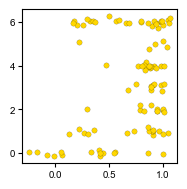

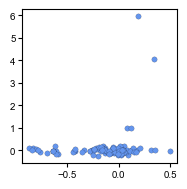

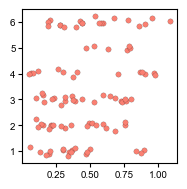

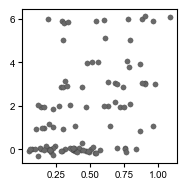

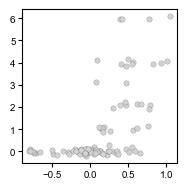

In [33]:
plt.rcParams['figure.figsize'] = (2,2)
for i in range (ntypes) :
    plt.scatter (Ydif[i,:],nPaths[i,:]+np.random.normal (0,.1,nsims),  color=color_dict[scenarios[i]],
                 s=15, edgecolor='black', linewidth=.1)
    plt.show ()